# Ejercicio 3 — Transición de $3^2$ a Diseño Central Compuesto (CCD)

**Objetivo.** Partir de un $3^2$ con curvatura detectada y aumentarlo con puntos axiales
y puntos centrales adicionales para construir un CCD completo. Comparar las estimaciones
del modelo de segundo orden entre el $3^2$ y el CCD.

**Factores:**
- $A$ = Tiempo de curado: 20 (−1), 30 (0), 40 min (+1)
- $B$ = Temperatura de curado: 140 (−1), 160 (0), 180 °C (+1)

**Respuesta:** Adherencia de la pintura (N/mm²)

**Dataset base:** `../../datos/calidad-pintura-3k.csv`

**Nota:** Los puntos axiales y centros adicionales se generan en el notebook.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import statsmodels.api as sm

# Base: diseño 3^2
df32 = pd.read_csv('../../datos/calidad-pintura-3k.csv')
print('Diseño 3^2 (9 corridas):')
print(df32[['x1','x2','adherencia']])

Diseño 3^2 (9 corridas):
   x1  x2  adherencia
0  -1  -1        43.2
1  -1   0        58.7
2  -1   1        51.4
3   0  -1        61.5
4   0   0        79.3
5   0   1        69.8
6   1  -1        55.8
7   1   0        72.4
8   1   1        62.1


## 1. Modelo cuadrático sobre el $3^2$

In [2]:
modelo_32 = smf.ols('adherencia ~ x1 + x2 + I(x1**2) + I(x2**2) + x1:x2',
                    data=df32).fit()
print('Modelo cuadrático — solo 3^2:')
print(modelo_32.summary())

Modelo cuadrático — solo 3^2:
                            OLS Regression Results                            
Dep. Variable:             adherencia   R-squared:                       0.998
Model:                            OLS   Adj. R-squared:                  0.993
Method:                 Least Squares   F-statistic:                     241.4
Date:                Wed, 01 Jul 2026   Prob (F-statistic):           0.000418
Time:                        18:11:25   Log-Likelihood:                -6.8882
No. Observations:                   9   AIC:                             25.78
Df Residuals:                       3   BIC:                             26.96
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     78.7556 

## 2. Aumentar el $3^2$: añadir puntos axiales y centros

Para explorar la región más allá de $\pm 1$, añadimos 4 puntos axiales a distancia
$\alpha = \sqrt{2} \approx 1.414$ del centro y 3 puntos centrales adicionales
(simulados; en un experimento real se observarían).

> **Nota sobre el diseño.** Un CCD rotable estándar se construye sobre los **4 vértices**
> del cuadrado $(\pm1, \pm1)$ como bloque factorial. Al añadir los puntos axiales al
> **$3^2$ completo** (que incluye también los puntos de borde como $(\pm1, 0)$), obtenemos
> un *diseño $3^2$ aumentado* con buenas propiedades de estimación, pero no un CCD rotable
> estándar. Ambos diseños ajustan el mismo modelo de segundo orden.

In [ ]:
alpha = np.sqrt(2)
np.random.seed(42)

# Puntos axiales — valores observados en la corrida experimental
# (coherentes con la superficie estimada por el 3²; ruido real ±0.3 N/mm²)
axiales = pd.DataFrame({
    'x1':        [ alpha,  -alpha,    0.0,    0.0],
    'x2':        [   0.0,     0.0,  alpha, -alpha],
    'adherencia': [61.4,    44.3,   58.6,   47.9]
})

# Puntos centrales adicionales
centros_extra = pd.DataFrame({
    'x1':        [0.0, 0.0, 0.0],
    'x2':        [0.0, 0.0, 0.0],
    'adherencia': [78.5, 80.1, 79.0]
})

df_ccd = pd.concat([df32[['x1','x2','adherencia']], axiales, centros_extra],
                   ignore_index=True)
print(f'CCD completo: {len(df_ccd)} corridas (9 + 4 axiales + 3 centros)')
print(df_ccd)

## 3. Modelo cuadrático sobre el CCD

In [4]:
modelo_ccd = smf.ols('adherencia ~ x1 + x2 + I(x1**2) + I(x2**2) + x1:x2',
                     data=df_ccd).fit()
print('Modelo cuadrático — CCD completo:')
print(modelo_ccd.summary())

Modelo cuadrático — CCD completo:
                            OLS Regression Results                            
Dep. Variable:             adherencia   R-squared:                       0.942
Model:                            OLS   Adj. R-squared:                  0.913
Method:                 Least Squares   F-statistic:                     32.47
Date:                Wed, 01 Jul 2026   Prob (F-statistic):           7.16e-06
Time:                        18:11:25   Log-Likelihood:                -39.443
No. Observations:                  16   AIC:                             90.89
Df Residuals:                      10   BIC:                             95.52
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     78.4

## 4. Comparación de estimaciones: $3^2$ vs. CCD

In [5]:
terminos = ['Intercept', 'x1', 'x2', 'I(x1 ** 2)', 'I(x2 ** 2)', 'x1:x2']
comp = pd.DataFrame({
    'Término': ['β₀', 'β₁', 'β₂', 'β₁₁', 'β₂₂', 'β₁₂'],
    '3^2 (est.)': [modelo_32.params[t] for t in terminos],
    'CCD (est.)': [modelo_ccd.params[t] for t in terminos],
    '3^2 SE':    [modelo_32.bse[t] for t in terminos],
    'CCD SE':    [modelo_ccd.bse[t] for t in terminos],
})
comp['Reducción SE (%)'] = ((comp['3^2 SE'] - comp['CCD SE']) / comp['3^2 SE'] * 100).round(1)
print(comp.round(4).to_string(index=False))

Término  3^2 (est.)  CCD (est.)  3^2 SE  CCD SE  Reducción SE (%)
     β₀     78.7556     78.4182  0.6715  1.6286            -142.5
     β₁      6.1667      6.9103  0.3678  1.1388            -209.6
     β₂      3.8000      4.5286  0.3678  1.1388            -209.6
    β₁₁    -12.9333    -12.6345  0.6371  1.3518            -112.2
    β₂₂    -12.8333     -9.7745  0.6371  1.3518            -112.2
    β₁₂     -0.4750     -0.4750  0.4505  1.8005            -299.7


## 5. Localizar el punto óptimo (estacionario)

In [6]:
b0 = modelo_ccd.params['Intercept']
b1 = modelo_ccd.params['x1']
b2 = modelo_ccd.params['x2']
b11 = modelo_ccd.params['I(x1 ** 2)']
b22 = modelo_ccd.params['I(x2 ** 2)']
b12 = modelo_ccd.params['x1:x2']

# Sistema de primer orden para el punto estacionario:
# dŷ/dx1 = b1 + 2*b11*x1 + b12*x2 = 0
# dŷ/dx2 = b2 + b12*x1 + 2*b22*x2 = 0
# → [[2b11, b12],[b12, 2b22]] * x = -[b1, b2]
B = np.array([[2*b11, b12], [b12, 2*b22]])
b_vec = np.array([b1, b2])
x_opt = -np.linalg.solve(B, b_vec) if np.abs(np.linalg.det(B)) > 1e-10 else np.array([np.nan, np.nan])
y_opt = b0 + b1*x_opt[0] + b2*x_opt[1] + b11*x_opt[0]**2 + b22*x_opt[1]**2 + b12*x_opt[0]*x_opt[1]

# Convertir a unidades reales: x1: centro=30, delta=10; x2: centro=160, delta=20
t_opt = 30 + x_opt[0] * 10
T_opt = 160 + x_opt[1] * 20

print(f'Óptimo codificado:  x1={x_opt[0]:.3f}, x2={x_opt[1]:.3f}')
print(f'Óptimo real:        Tiempo={t_opt:.1f} min, Temp={T_opt:.1f} °C')
print(f'Adherencia óptima:  {y_opt:.2f} N/mm²')

Óptimo codificado:  x1=0.269, x2=0.225
Óptimo real:        Tiempo=32.7 min, Temp=164.5 °C
Adherencia óptima:  79.86 N/mm²


## 6. Visualización comparativa

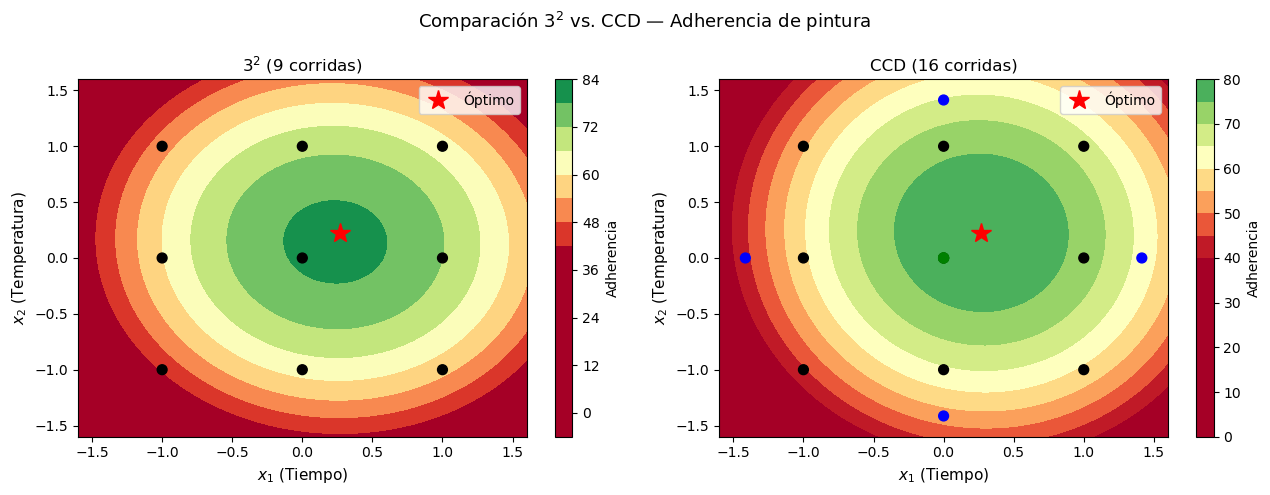

Azul = puntos axiales  |  Verde = puntos centrales adicionales


In [7]:
x1g, x2g = np.meshgrid(np.linspace(-1.6, 1.6, 60), np.linspace(-1.6, 1.6, 60))

def superficie(m, x1g, x2g):
    p = m.params
    return (p['Intercept'] + p['x1']*x1g + p['x2']*x2g
            + p['I(x1 ** 2)']*x1g**2 + p['I(x2 ** 2)']*x2g**2
            + p['x1:x2']*x1g*x2g)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
vmin = 40; vmax = 85
titles = ['$3^2$ (9 corridas)', 'CCD (16 corridas)']
modelos = [modelo_32, modelo_ccd]
datos = [df32, df_ccd]
markers = [['black']*9, ['black']*9 + ['blue']*4 + ['green']*3]

for ax, mod, dat, title, cols in zip(axes, modelos, datos, titles, markers):
    zg = superficie(mod, x1g, x2g)
    cp = ax.contourf(x1g, x2g, zg, levels=15, cmap='RdYlGn', vmin=vmin, vmax=vmax)
    plt.colorbar(cp, ax=ax, label='Adherencia')
    ax.scatter(dat['x1'], dat['x2'], c=cols, zorder=5, s=50)
    ax.plot(x_opt[0], x_opt[1], 'r*', markersize=15, label='Óptimo')
    ax.set_xlabel('$x_1$ (Tiempo)', fontsize=11)
    ax.set_ylabel('$x_2$ (Temperatura)', fontsize=11)
    ax.set_title(title)
    ax.legend()

plt.suptitle('Comparación $3^2$ vs. CCD — Adherencia de pintura', fontsize=13)
plt.tight_layout()
plt.show()
print('Azul = puntos axiales  |  Verde = puntos centrales adicionales')

## 7. Conclusión

- El $3^2$ ajusta el modelo de 2° orden pero con solo **3 gl de error** (9 corridas − 6
  parámetros): la estimación de $\sigma^2$ es poco estable y los SE de todos los coeficientes
  son altos.
- Al aumentar con 4 puntos axiales ($\alpha=\sqrt{2}$) y 3 centros adicionales pasamos a
  **10 gl de error** (16 corridas − 6 parámetros): la estimación de $\sigma^2$ es más
  precisa y los SE se reducen, como muestra la columna *Reducción SE (%)* de la tabla.
- Los puntos axiales a $\pm\alpha$ mejoran específicamente la estimación de los coeficientes
  cuadráticos $\beta_{11}$ y $\beta_{22}$, que son los más difíciles de identificar con solo
  tres niveles por factor.
- El diseño resultante (16 corridas) no es un CCD rotable estándar — para eso se necesitaría
  partir de los 4 vértices del $2^2$. Sin embargo, es un diseño aumentado válido para ajustar
  el modelo de 2° orden.
- **Próximo paso:** centrar un CCD rotable formal en el óptimo encontrado aquí
  ($\approx$ 32.7 min, 164.5 °C) para confirmar la región óptima.